In [1]:
# import dependencies
%matplotlib inline
import os
import sys
import spatioev as se
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Scimap
import scimap as sm

from spatioev.config import ClusteringConfig

Running SCIMAP  2.3.5


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
from spatioev import (
    ripleys_k,
    ripleys_k_by_image,
    ripleys_k_by_phenotype,
    cross_ripleys_k,
    cross_ripleys_k_by_phenotype,
    cross_ripleys_k_all_pairs,
    cross_ripleys_curve,
    cross_ripleys_curve_by_phenotype,
    morans_i,
    morans_i_by_image,
    local_morans_i,
    add_local_morans_i
)

In [3]:
# set a working directory
wdir = ('/Users/shihongwu/SpatioEv')
os.chdir(wdir)

In [4]:
adata = se.load_h5ad("data/exp_1.h5ad")
adata

AnnData object with n_obs × n_vars = 51932 × 25
    obs: 'label', 'area', 'eccentricity', 'major_axis_length', 'minor_axis_length', 'perimeter', 'convex_area', 'equivalent_diameter', 'orientation', 'solidity', 'feret_diameter_max', 'Y_centroid', 'X_centroid', 'major_minor_axis_ratio', 'perim_square_over_area', 'major_axis_equiv_diam_ratio', 'convex_hull_resid', 'centroid_dif', 'num_concavities', 'circularity', 'fractal_dimension', 'boundary_irregularity', 'nc_ratio', 'cell_size_nuclear', 'CD11c_nuclear', 'CD14_nuclear', 'CD146_nuclear', 'CD19_nuclear', 'CD3_nuclear', 'CD31_nuclear', 'CD4_nuclear', 'CD45_nuclear', 'CD68_nuclear', 'CD90_nuclear', 'CK19_nuclear', 'COL1A1_nuclear', 'COL4A1_nuclear', 'COL6A1_nuclear', 'FN_nuclear', 'HLADR_nuclear', 'IGFBP5_nuclear', 'NaKATPase_nuclear', 'PCK_nuclear', 'PDPN_nuclear', 'RS6_nuclear', 'SMA_nuclear', 'Tenascin_nuclear', 'Vimentin_nuclear', 'dapi_nuclear', 'label_nuclear', 'area_nuclear', 'eccentricity_nuclear', 'major_axis_length_nuclear', 'min

In [5]:
# 1) Read annotations CSV (saved from adata_final.obs.to_csv, so index is first column)
ann = pd.read_csv("results/svm_phenotyping_results.csv", index_col=0)

# 2) Optional: keep only columns you want
ann = ann[["annotated_clusters_update3", "svm_prediction"]]

# 3) Join into adata.obs by cell ID (index)
adata.obs = adata.obs.join(ann, how="left")

### Ripley’s K — global clustering

In [6]:
ripley_image = ripleys_k_by_image(
    adata,
    radius=50,
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid"
)

ripley_image

,imageid,ripley_k
0,exp,23353.912891


Visualize:

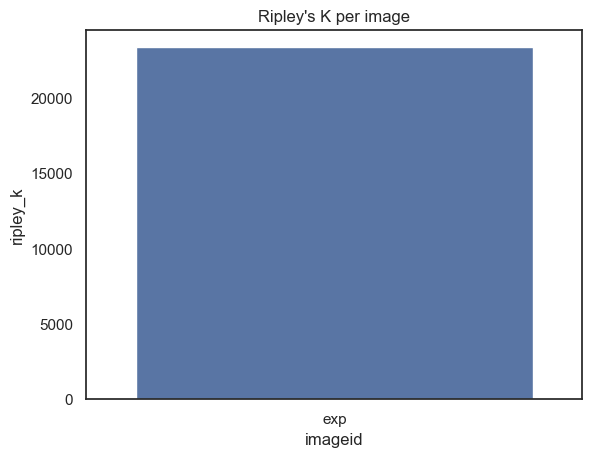

In [7]:
sns.barplot(
    data=ripley_image,
    x="imageid",
    y="ripley_k"
)

plt.title("Ripley's K per image")
plt.show()

### Ripley’s K by phenotype

In [8]:
ripley_pheno = ripleys_k_by_phenotype(
    adata,
    phenotype_key="annotated_clusters_update3",
    radius=50,
    x_key="X_centroid",
    y_key="Y_centroid",
)

ripley_pheno.head()

,imageid,phenotype,ripley_k
0,exp,noise,223445.897408
1,exp,tumour,39499.466104
2,exp,CD90+ CAFs,396120.847245
3,exp,myCAFs,63142.846918
4,exp,PDPN+ CAFs,170959.042932


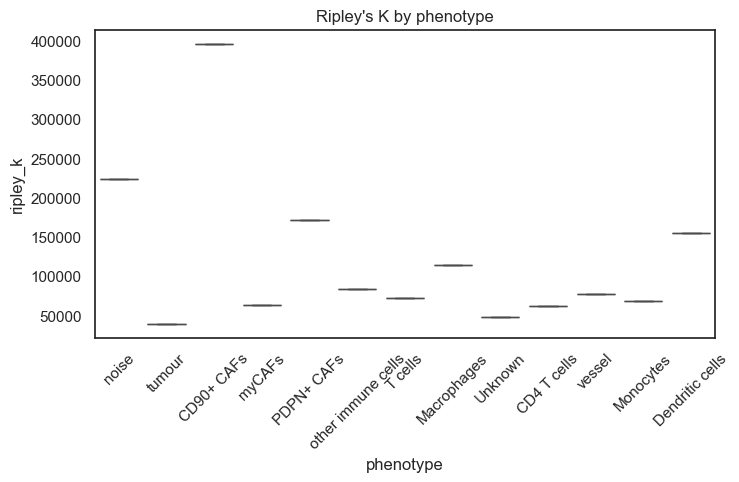

In [9]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=ripley_pheno,
    x="phenotype",
    y="ripley_k"
)

plt.xticks(rotation=45)
plt.title("Ripley's K by phenotype")
plt.show()

### Cross-phenotype Ripley

In [10]:
cross_ripleys_k_by_phenotype(
    adata,
    phenotype_key="annotated_clusters_update3",
    source_phenotype="tumour",
    target_phenotype="CD4 T cells",
    radius=50
)

,imageid,source,target,cross_ripley_k
0,exp,tumour,CD4 T cells,5217.873979


<Axes: xlabel='target', ylabel='source'>

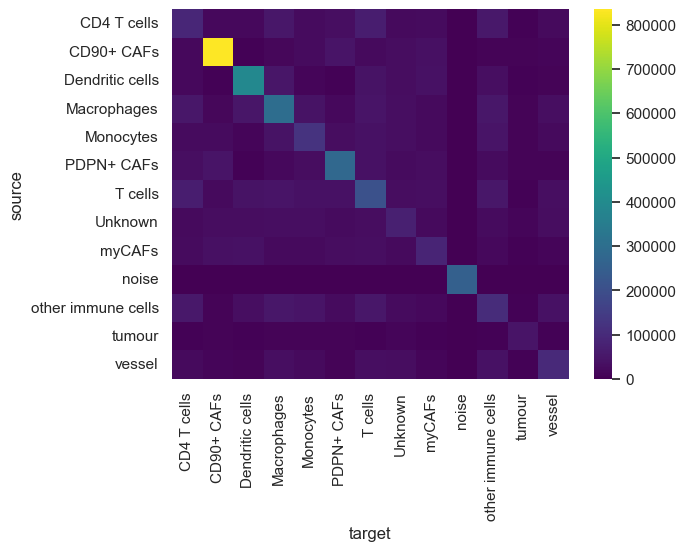

In [11]:
res = cross_ripleys_k_all_pairs(
    adata,
    phenotype_key="annotated_clusters_update3",
    radius=50
)

pivot = res.pivot_table(
    index="source",
    columns="target",
    values="cross_ripley_k"
)

sns.heatmap(pivot, cmap="viridis")

In [12]:
radii = np.linspace(10,200,30)

curve = cross_ripleys_curve_by_phenotype(
    adata,
    phenotype_key="annotated_clusters_update3",
    source_phenotype="T cells",
    target_phenotype="tumour",
    radii=radii
)

curve.head()

,radius,K,L,L_minus_r,imageid,source,target
0,10.000000,0.000000,0.000000,-10.000000,exp,T cells,tumour
1,16.551724,58.637718,4.320297,-12.231427,exp,T cells,tumour
2,23.103448,768.805635,15.643479,-7.459969,exp,T cells,tumour
3,29.655172,1707.009121,23.310038,-6.345134,exp,T cells,tumour
4,36.206897,2860.217573,30.173424,-6.033472,exp,T cells,tumour


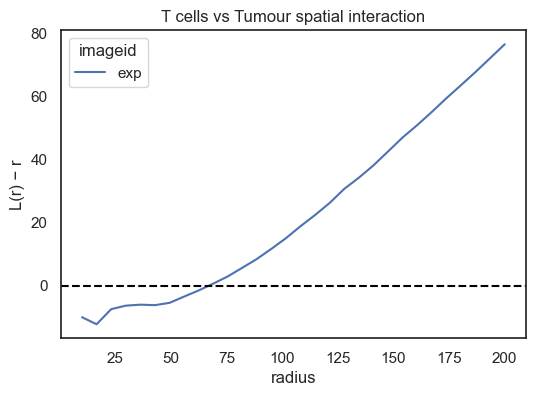

In [13]:
plt.figure(figsize=(6,4))

sns.lineplot(
    data=curve,
    x="radius",
    y="L_minus_r",
    hue="imageid"
)

plt.axhline(0,color="black",linestyle="--")

plt.ylabel("L(r) − r")
plt.title("T cells vs Tumour spatial interaction")

plt.show()

In [14]:
phenotypes = adata.obs["annotated_clusters_update3"].unique()

results = []

for p1 in phenotypes:
    for p2 in phenotypes:

        curve = cross_ripleys_curve_by_phenotype(
            adata,
            phenotype_key="annotated_clusters_update3",
            source_phenotype=p1,
            target_phenotype=p2,
            radii=radii
        )

        results.append(curve)

ripley_all = pd.concat(results)

In [15]:
ripley_all["radius"].iloc[18]

127.93103448275862

<Axes: xlabel='target', ylabel='source'>

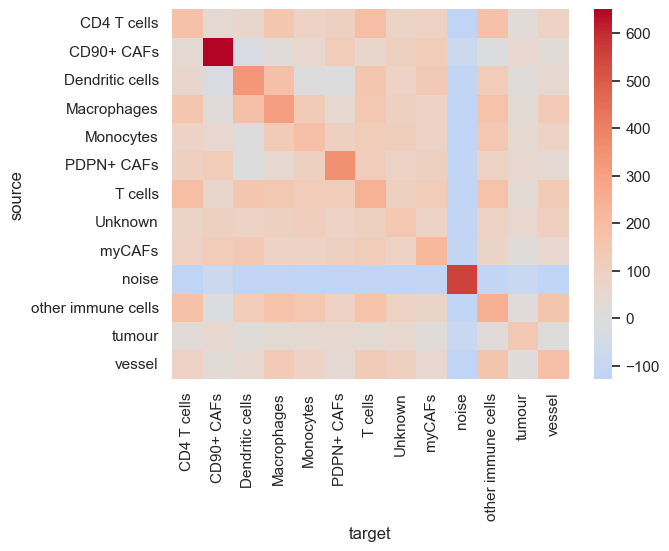

In [16]:
subset = ripley_all[ripley_all["radius"] == ripley_all["radius"].iloc[18]]

pivot = subset.pivot_table(
    index="source",
    columns="target",
    values="L_minus_r"
)

sns.heatmap(pivot, cmap="coolwarm", center=0)

### Moran’s I test

In [17]:
cx = adata.obs["X_centroid"].mean()
cy = adata.obs["Y_centroid"].mean()

adata.obs["distance_center"] = np.sqrt(
    (adata.obs["X_centroid"]-cx)**2 +
    (adata.obs["Y_centroid"]-cy)**2
)

In [18]:
morans_i_by_image(
    adata,
    value_key="distance_center",
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid"
)

,imageid,morans_i
0,exp,0.999966


### Moran’s I for phenotype density

In [19]:
adata.obs["is_tumor"] = (
    adata.obs["annotated_clusters_update3"] == "tumour"
).astype(int)

In [20]:
morans_i_by_image(
    adata,
    value_key="is_tumor"
)

,imageid,morans_i
0,exp,0.7533


### Local Moran’s I

In [21]:
adata = add_local_morans_i(
    adata,
    value_key="is_tumor",
    x_key="X_centroid",
    y_key="Y_centroid",
)

In [22]:
adata.obs["local_morans_i__is_tumor"].describe()

count    51932.000000
mean         6.026400
std          3.252826
min         -8.000000
25%          4.064584
50%          7.914806
75%          8.086111
max          8.086111
Name: local_morans_i__is_tumor, dtype: float64

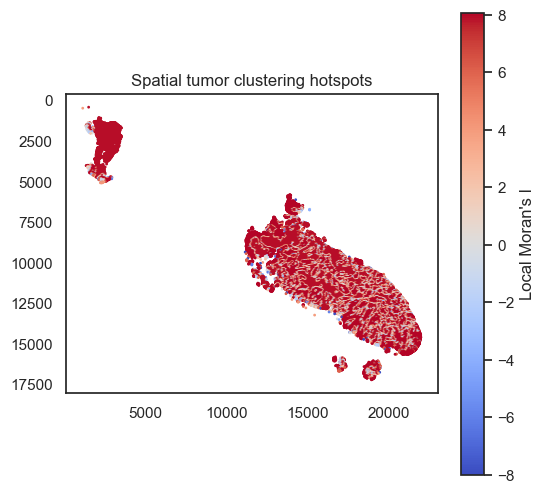

In [23]:
plt.figure(figsize=(6,6))

plt.scatter(
    adata.obs["X_centroid"],
    adata.obs["Y_centroid"],
    c=adata.obs["local_morans_i__is_tumor"],
    cmap="coolwarm",
    s=1
)

plt.colorbar(label="Local Moran's I")
plt.title("Spatial tumor clustering hotspots")
plt.gca().set_aspect("equal")
plt.gca().invert_yaxis()  # Invert y-axis to match image orientation

plt.show()